# 10 - Attention Mechanism



---

In the previous notebook, we learned about the Encoder-Decoder (Seq2Seq) architecture.

Although Seq2Seq worked well, it had one major limitation:

The entire input sentence had to be compressed into a single Context Vector.

Researchers asked:

"What if the decoder could look back at different words whenever it needed?"

This idea became **Attention**.

## 📜 History

Seq2Seq models worked well for short sentences.

However, when sentences became longer, translation quality decreased.

Example:

"I started learning programming five years ago when I entered college and today I work on Artificial Intelligence."

Compressing this entire sentence into one vector caused information loss.

In 2014, researchers introduced the **Attention Mechanism**.

Instead of remembering everything in one vector, the Decoder could focus on the most relevant input words while generating each output word.

This was a major breakthrough in NLP.

## ❌ The Context Vector Bottleneck

Seq2Seq Architecture

Input Sentence

↓

Encoder

↓

One Context Vector

↓

Decoder

↓

Output Sentence

Problem:

One fixed vector cannot perfectly represent long sentences.

Important information may be lost.

Researchers wanted the Decoder to "look back" at the Encoder outputs whenever needed.

## 💡 Think Like a Researcher

Imagine you're building Google Translate.

Sentence:

"The animal didn't cross the street because it was tired."

While translating the word:

it

Should the Decoder focus on:

- animal
- street
- cross
- tired

Humans immediately know that "it" refers to the animal.

Can a neural network learn the same behavior?

Attention was the answer.

## 💡 Core Idea

Attention allows the Decoder to focus on different input words at different time steps.

Instead of using only one Context Vector,

the Decoder computes a **new context** for every output word.

Different output words can attend to different input words.

## 🧠 Human Analogy

Imagine answering a question from a textbook.

You don't memorize the entire chapter.

Instead, you look back at the relevant paragraph before answering.

Attention works in the same way.

The model looks back at the important parts of the input whenever needed.

In [ ]:
sentence = ["The", "cat", "sat", "on", "the", "mat"]

print(sentence)

['The', 'cat', 'sat', 'on', 'the', 'mat']


Ask:

If we want to understand the word sat, which nearby words are most important?

Probably:

cat
on
mat

Not every word is equally important.

### Higher score ---> More attention

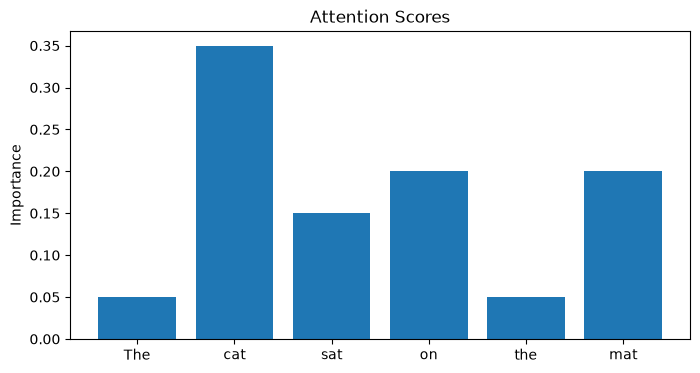

In [3]:
import matplotlib.pyplot as plt

words = ["The","cat","sat","on","the","mat"]

scores = [0.05,0.35,0.15,0.20,0.05,0.20]

plt.figure(figsize=(8,4))

plt.bar(words,scores)

plt.title("Attention Scores")

plt.ylabel("Importance")

plt.show()

In [7]:
words = [
    "The",
    "animal",
    "didn't",
    "cross",
    "the",
    "street",
    "because",
    "it",
    "was",
    "tired"
]

print(words)

# Ask:

# When predicting it

# Which word deserves the highest attention?

['The', 'animal', "didn't", 'cross', 'the', 'street', 'because', 'it', 'was', 'tired']


In [8]:
import numpy as np
import pandas as pd

attention = np.array([
    [0.05,0.60,0.05,0.05,0.05,0.05,0.05,0.05,0.03,0.02]
])

pd.DataFrame(
    attention,
    columns=words,
    index=["it"]
)


#The highest score is for animal, meaning the model focuses most on that word.

,The,animal,didn't,cross,the,street,because,it,was,tired
it,0.05,0.6,0.05,0.05,0.05,0.05,0.05,0.05,0.03,0.02


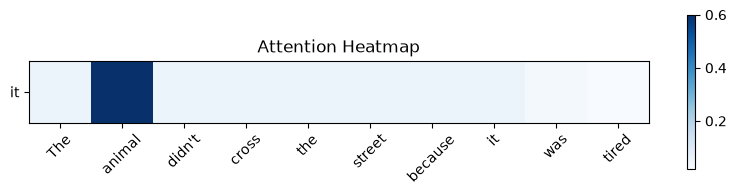

In [9]:
plt.figure(figsize=(10,2))

plt.imshow(attention,cmap="Blues")

plt.xticks(range(len(words)),words,rotation=45)

plt.yticks([0],["it"])

plt.colorbar()

plt.title("Attention Heatmap")

plt.show()

## ➗ Mathematics (Intuition)

Attention computes a score for every input word.

Higher score

↓

More important

Lower score

↓

Less important

Finally,

the model computes a weighted average of the input representations.

You do not need to memorize the equations yet.

Focus on the intuition:

The model learns **where to look**.

## 🔑 Query, Key, Value

Every token creates three vectors.

### Query (Q)

What am I looking for?

### Key (K)

What information do I contain?

### Value (V)

What information should I pass?

Attention compares the Query with all Keys.

The matching Values receive higher importance.

## 🍽 Restaurant Analogy

Imagine you order food.

You (Query)

↓

Waiter checks every menu item (Keys)

↓

Chooses the best match

↓

Brings the food (Value)

Attention works similarly.

The Query searches for the most relevant Keys and retrieves the corresponding Values.

In [11]:
import numpy as np

scores = np.array([2.0,1.0,0.5])

softmax = np.exp(scores)/np.sum(np.exp(scores))

print(softmax)

# Softmax converts raw scores into probabilities.

# All values sum to 1.

[0.62853172 0.2312239  0.14024438]


## ✅ Advantages

- Better translation
- Better long-sequence understanding
- Dynamic context
- Improved language understanding
- Foundation of modern NLP

## ❌ Remaining Limitation

Attention improved Seq2Seq.

However,

the Encoder and Decoder still used

- RNN
- LSTM
- GRU

These models process words sequentially.

Training was still slow.

Researchers asked:

"Can we remove recurrence completely?"

This question led to the Transformer.

## 🌍 Applications

Attention is used in

- Machine Translation
- Text Summarization
- Speech Recognition
- Chatbots
- Image Captioning
- Question Answering

## ✅ Summary

Today I learned

- Why Attention was invented.
- The Context Vector bottleneck.
- Dynamic context.
- Query, Key and Value intuition.
- Softmax intuition.
- Attention visualization.